In [ ]:
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
x = iris.data[:50, 0]
y = iris.data[:50, 1]

x_mean = np.mean(x)
y_mean = np.mean(y)

m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
c = y_mean - m * x_mean

print("Slope (m):", m)
print("Intercept (c):", c)


Slope (m): 0.7985283006471532
Intercept (c): -0.5694326730396493


Intercept (c): -0.5694326730399227
Slope (m): 0.7985283006471879


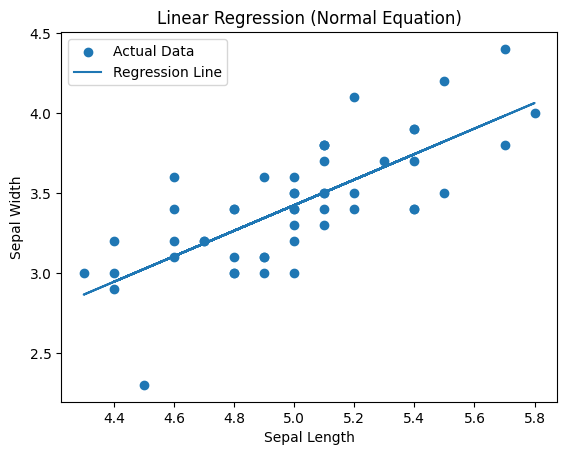

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()

x = iris.data[:50, 0]
y = iris.data[:50, 1]

X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

bias = np.ones((X.shape[0], 1))
X_bias = np.hstack((bias, X))

W = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

c = W[0, 0]
m = W[1, 0]

print("Intercept (c):", c)
print("Slope (m):", m)

y_pred = m * x + c

plt.scatter(x, y, label="Actual Data")
plt.plot(x, y_pred, label="Regression Line")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Linear Regression (Normal Equation)")
plt.legend()
plt.show()


Intercept (c): 0.09923935376512227
Slope (m): 0.665575509300158


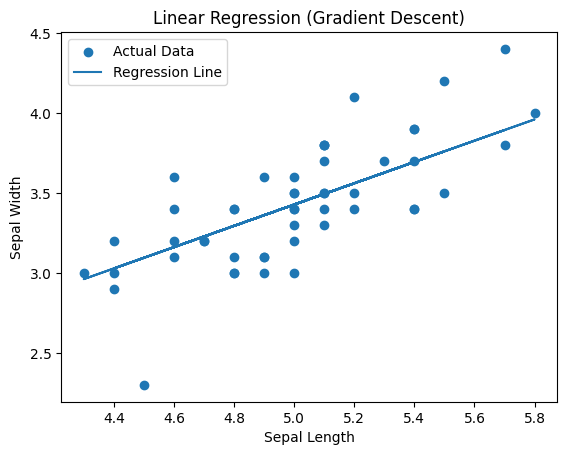

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()

x = iris.data[:50, 0]
y = iris.data[:50, 1]

X = x.reshape(-1, 1)
Y = y

X = np.c_[np.ones((X.shape[0], 1)), X]

theta = np.zeros(X.shape[1])

learning_rate = 0.01
iterations = 1000
m = len(Y)

for i in range(iterations):
   predictions = np.dot(X, theta)
   errors = predictions - Y
   gradient = np.dot(X.T, errors) / m
   theta -= learning_rate * gradient

c = theta[0]
m_value = theta[1]

print("Intercept (c):", c)
print("Slope (m):", m_value)

y_pred = m_value * x + c

plt.scatter(x, y, label="Actual Data")
plt.plot(x, y_pred, label="Regression Line")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Linear Regression (Gradient Descent)")
plt.legend()
plt.show()


Slope (m): 0.798528300647153
Intercept (c): -0.569432673039648


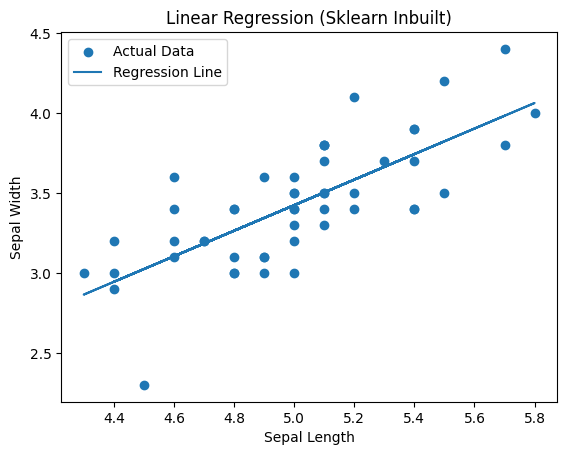

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()

x = iris.data[:50, 0].reshape(-1, 1)
y = iris.data[:50, 1]

model = LinearRegression()
model.fit(x, y)

m = model.coef_[0]
c = model.intercept_

print("Slope (m):", m)
print("Intercept (c):", c)

y_pred = model.predict(x)

plt.scatter(x, y, label="Actual Data")
plt.plot(x, y_pred, label="Regression Line")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Linear Regression (Sklearn Inbuilt)")
plt.legend()
plt.show()


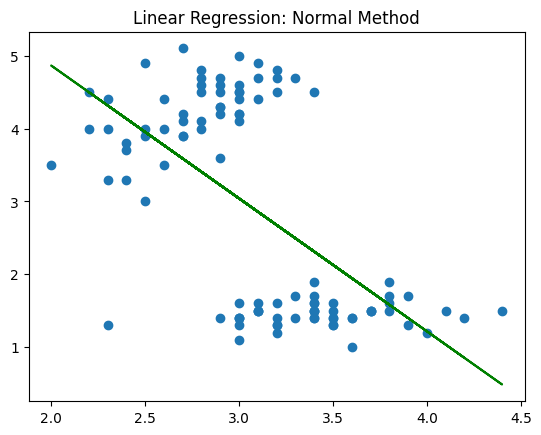

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
iris = load_iris()
X = iris.data[:100, 1].reshape(-1, 1)
Y = iris.data[:100, 2].reshape(-1, 1)
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
# Matrix Calculation
W = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y
Y_pred = X_bias @ W
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='green')
plt.title("Linear Regression: Normal Method")
plt.show()


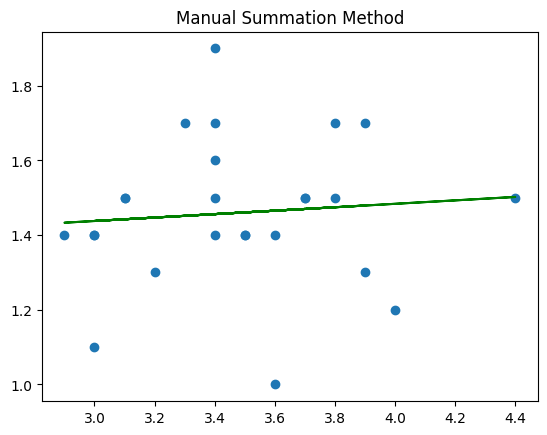

In [ ]:
X_sub = iris.data[:25, 1]
Y_sub = iris.data[:25, 2]
n = len(X_sub)

sum_x = sum_y = sum_xy = sum_x2 = 0
for i in range(n):
    sum_x += X_sub[i]
    sum_y += Y_sub[i]
    sum_xy += X_sub[i] * Y_sub[i]
    sum_x2 += X_sub[i] * X_sub[i]

m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
b = (sum_y - m * sum_x) / n
Y_pred = b + m * X_sub

plt.scatter(X_sub, Y_sub)
plt.plot(X_sub, Y_pred, color='green')
plt.title("Manual Summation Method")
plt.show()


MSE: 1.6540505625059752
R2 Score: 0.19490353374658942


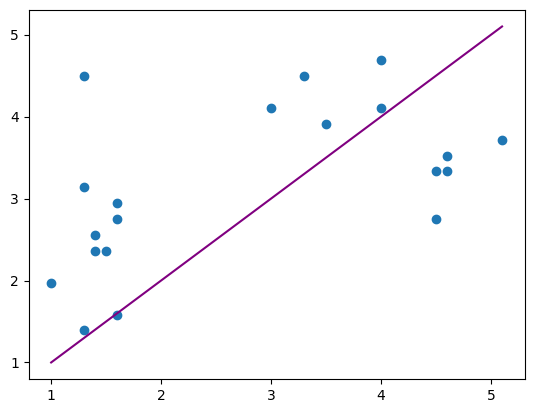

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=11)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='purple')
plt.show()


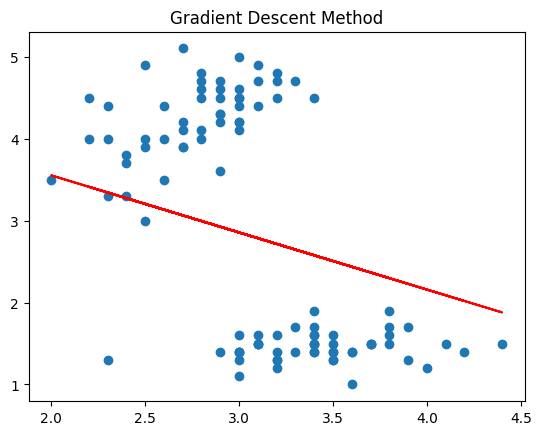

In [ ]:
m, c = 0.0, 0.0
L = 0.01  # Learning rate
epochs = 2000
n = float(len(X))

for i in range(epochs):
    Y_p = m * X.flatten() + c
    dm = (-2/n) * sum(X.flatten() * (Y.flatten() - Y_p))
    dc = (-2/n) * sum(Y.flatten() - Y_p)
    m = m - L * dm
    c = c - L * dc
plt.scatter(X, Y)
plt.plot(X, m*X + c, color='red')
plt.title("Gradient Descent Method")
plt.show()


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

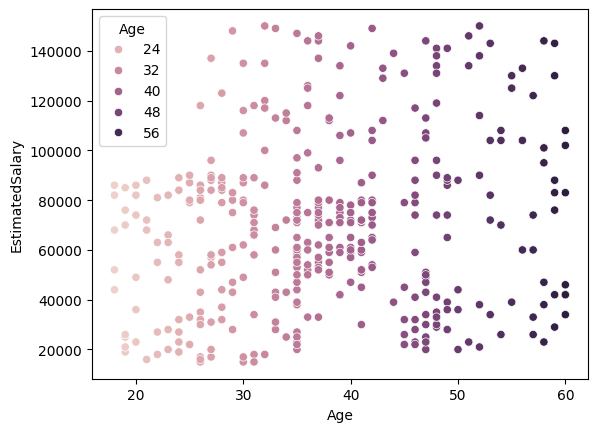

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
purchase_data = pd.read_csv('Car_dataset.csv')
purchase_data.head(10)
sns.scatterplot(x=purchase_data['Age'], y=purchase_data['EstimatedSalary'], hue= purchase_data['Age'])